<a href="https://colab.research.google.com/github/SaiVarshitha-SV/AI-Driven-Phishing-Email-Detection-Using-Natural-Language-Processing-NLP-/blob/main/Phishing_Email_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

print("=" * 60)
print("All Required Libraries Imported Successfully")
print("=" * 60)

All Required Libraries Imported Successfully


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\srika\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# ==========================================================
# STEP 1 : LOAD THE DATASET
# ==========================================================

project_path = r"C:\B.Tech\Projects\IICT Project 2"

data = pd.read_csv(project_path + r"\Phishing_Email.csv")

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print("\nDataset Shape:")
print(data.shape)

Dataset Loaded Successfully

Dataset Shape:
(18650, 3)


In [ ]:
# ==========================================================
# STEP 2 : EXPLORE THE DATASET
# ==========================================================

print("=" * 60)
print("Dataset Information")
print("=" * 60)

print("\nShape of Dataset:")
print(data.shape)

print("\nColumn Names:")
print(data.columns)

print("\nFirst Five Records:")
display(data.head())

Dataset Information

Shape of Dataset:
(18650, 3)

Column Names:
Index(['Unnamed: 0', 'Email Text', 'Email Type'], dtype='object')

First Five Records:


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [ ]:
# ==========================================================
# STEP 3 : PREPARE THE DATASET
# ==========================================================

# Remove unnecessary index column
data.drop(columns=["Unnamed: 0"], inplace=True)

# Convert labels into numerical values
data["label"] = data["Email Type"].map({
    "Safe Email": 0,
    "Phishing Email": 1
})

print("=" * 60)
print("Dataset Prepared Successfully")
print("=" * 60)

display(data.head())

Dataset Prepared Successfully


,Email Text,Email Type,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,0
1,the other side of * galicismos * * galicismo *...,Safe Email,0
2,re : equistar deal tickets are you still avail...,Safe Email,0
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,1
4,software at incredibly low prices ( 86 % lower...,Phishing Email,1


In [ ]:
# ==========================================================
# STEP 4 : INSPECT DATASET
# ==========================================================

print("=" * 60)
print("Dataset Information")
print("=" * 60)

print("\nData Types")
print(data.dtypes)

print("\n")

print("=" * 60)
print("Missing Values")
print("=" * 60)

print(data.isnull().sum())

print("\n")

print("=" * 60)
print("Duplicate Records")
print("=" * 60)

print(data.duplicated().sum())

Dataset Information

Data Types
Email Text    object
Email Type    object
label          int64
dtype: object


Missing Values
Email Text    16
Email Type     0
label          0
dtype: int64


Duplicate Records
1111


In [ ]:
# ==========================================================
# STEP 5 : CLEAN THE DATASET
# ==========================================================

data = data.drop_duplicates()

data = data.dropna()

data = data.reset_index(drop=True)

print("=" * 60)
print("Dataset Cleaned Successfully")
print("=" * 60)

print("\nNew Dataset Shape:")
print(data.shape)

display(data.head())

Dataset Cleaned Successfully

New Dataset Shape:
(17538, 3)


,Email Text,Email Type,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,0
1,the other side of * galicismos * * galicismo *...,Safe Email,0
2,re : equistar deal tickets are you still avail...,Safe Email,0
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,1
4,software at incredibly low prices ( 86 % lower...,Phishing Email,1


In [ ]:
# ==========================================================
# STEP 6 : TEXT PREPROCESSING
# ==========================================================

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    # Remove stop words
    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)


data["clean_text"] = data["Email Text"].apply(clean_text)

print("=" * 60)
print("Text Preprocessing Completed Successfully")
print("=" * 60)

display(data[["Email Text", "clean_text"]].head())

Text Preprocessing Completed Successfully


,Email Text,clean_text
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",disc uniformitarianism sex lang dick hudson ob...
1,the other side of * galicismos * * galicismo *...,side galicismos galicismo spanish term names i...
2,re : equistar deal tickets are you still avail...,equistar deal tickets still available assist r...
3,\nHello I am your hot lil horny toy.\n I am...,hello hot lil horny toy one dream open minded ...
4,software at incredibly low prices ( 86 % lower...,software incredibly low prices lower drapery s...


In [ ]:
# ==========================================================
# STEP 7 : COMPARE ORIGINAL AND CLEANED TEXT
# ==========================================================

comparison = data[["Email Text", "clean_text"]].head()

display(comparison)

,Email Text,clean_text
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",disc uniformitarianism sex lang dick hudson ob...
1,the other side of * galicismos * * galicismo *...,side galicismos galicismo spanish term names i...
2,re : equistar deal tickets are you still avail...,equistar deal tickets still available assist r...
3,\nHello I am your hot lil horny toy.\n I am...,hello hot lil horny toy one dream open minded ...
4,software at incredibly low prices ( 86 % lower...,software incredibly low prices lower drapery s...


In [ ]:
# ==========================================================
# STEP 8 : TF-IDF FEATURE EXTRACTION
# ==========================================================

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(data["clean_text"])

y = data["label"]

print("=" * 60)
print("TF-IDF Feature Extraction Completed")
print("=" * 60)

print("\nFeature Matrix Shape:")
print(X.shape)

print("\nTarget Variable Shape:")
print(y.shape)

TF-IDF Feature Extraction Completed

Feature Matrix Shape:
(17538, 5000)

Target Variable Shape:
(17538,)


In [ ]:
# ==========================================================
# STEP 9 : TRAIN-TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("Dataset Split Completed")
print("=" * 60)

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

Dataset Split Completed

Training Data Shape:
(14030, 5000)

Testing Data Shape:
(3508, 5000)


In [ ]:
# ==========================================================
# STEP 10 : TRAIN MACHINE LEARNING MODELS
# ==========================================================

models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=300,
        random_state=42
    ),

    "Naive Bayes": MultinomialNB(),

    "Linear SVM": LinearSVC(random_state=42)

}

results = {}

trained_models = {}

print("=" * 70)
print("TRAINING MACHINE LEARNING MODELS")
print("=" * 70)

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    trained_models[name] = model

    print(f"{name} Accuracy : {accuracy:.4f}")

print("\n")
print("=" * 70)
print("ALL MODELS TRAINED SUCCESSFULLY")
print("=" * 70)

TRAINING MACHINE LEARNING MODELS

Training Logistic Regression...
Logistic Regression Accuracy : 0.9706

Training Decision Tree...
Decision Tree Accuracy : 0.9145

Training Random Forest...
Random Forest Accuracy : 0.9729

Training Neural Network...
Neural Network Accuracy : 0.9735

Training Naive Bayes...
Naive Bayes Accuracy : 0.9609

Training Linear SVM...
Linear SVM Accuracy : 0.9775


ALL MODELS TRAINED SUCCESSFULLY


In [ ]:
# ==========================================================
# STEP 11 : MODEL COMPARISON
# ==========================================================

results_df = pd.DataFrame(
    results.items(),
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

display(results_df)

MODEL COMPARISON


,Model,Accuracy
0,Linear SVM,0.977480
1,Neural Network,0.973489
2,Random Forest,0.972919
3,Logistic Regression,0.970639
4,Naive Bayes,0.960946
5,Decision Tree,0.914481


MODEL ACCURACY COMPARISON


,Model,Accuracy
0,Linear SVM,0.977480
1,Neural Network,0.973489
2,Random Forest,0.972919
3,Logistic Regression,0.970639
4,Naive Bayes,0.960946
5,Decision Tree,0.914481


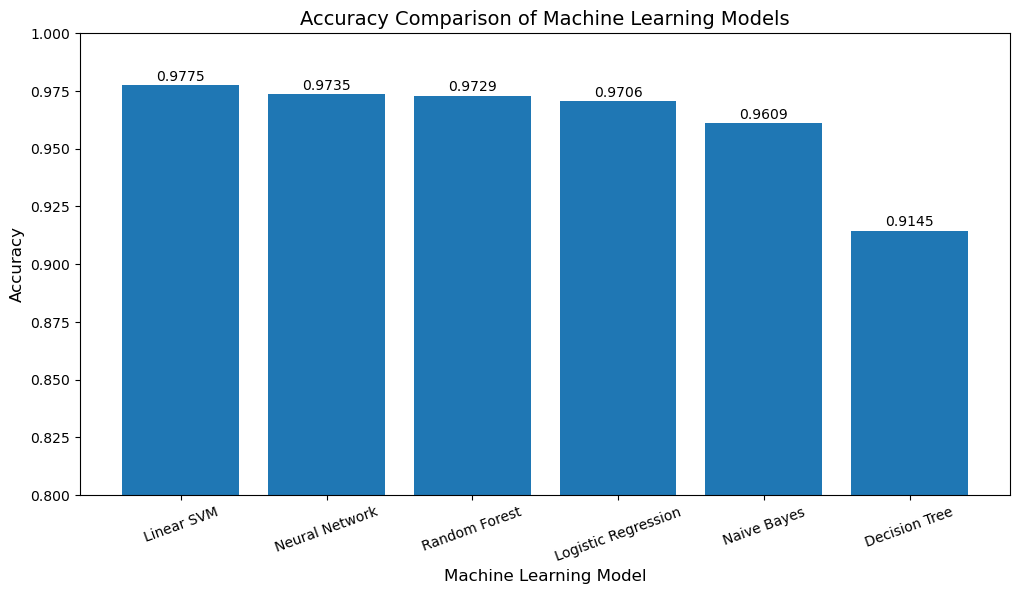

In [ ]:
# ==========================================================
# STEP 12 : ACCURACY COMPARISON GRAPH
# ==========================================================

print("=" * 70)
print("MODEL ACCURACY COMPARISON")
print("=" * 70)

# Display comparison table
display(results_df)

# Plot Accuracy Graph
plt.figure(figsize=(12,6))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Accuracy Comparison of Machine Learning Models", fontsize=14)

plt.xlabel("Machine Learning Model", fontsize=12)

plt.ylabel("Accuracy", fontsize=12)

plt.xticks(rotation=20)

plt.ylim(0.80,1.00)

for index, value in enumerate(results_df["Accuracy"]):
    plt.text(index, value + 0.002, f"{value:.4f}", ha='center')

plt.show()

In [ ]:
# ==========================================================
# STEP 13 : CLASSIFICATION REPORTS
# ==========================================================

print("=" * 80)
print("CLASSIFICATION REPORTS")
print("=" * 80)

predictions = {}

for name, model in trained_models.items():

    print("\n")
    print("=" * 80)
    print(name.upper())
    print("=" * 80)

    y_pred = model.predict(X_test)

    predictions[name] = y_pred

    print(classification_report(y_test, y_pred))

CLASSIFICATION REPORTS


LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      2196
           1       0.97      0.95      0.96      1312

    accuracy                           0.97      3508
   macro avg       0.97      0.97      0.97      3508
weighted avg       0.97      0.97      0.97      3508



DECISION TREE
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2196
           1       0.87      0.90      0.89      1312

    accuracy                           0.91      3508
   macro avg       0.91      0.91      0.91      3508
weighted avg       0.92      0.91      0.91      3508



RANDOM FOREST
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      2196
           1       0.96      0.97      0.96      1312

    accuracy                           0.97      3508
   macro avg       0.97      0.97      0.97      35



Logistic Regression


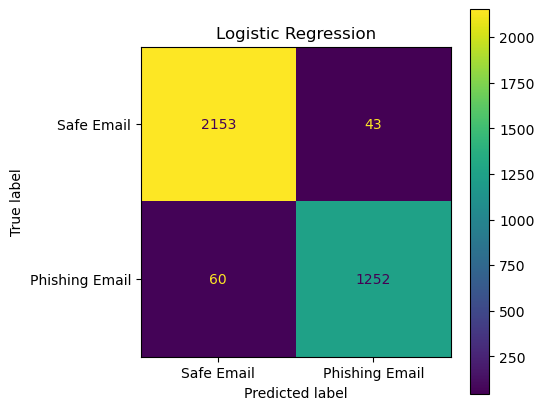



Decision Tree


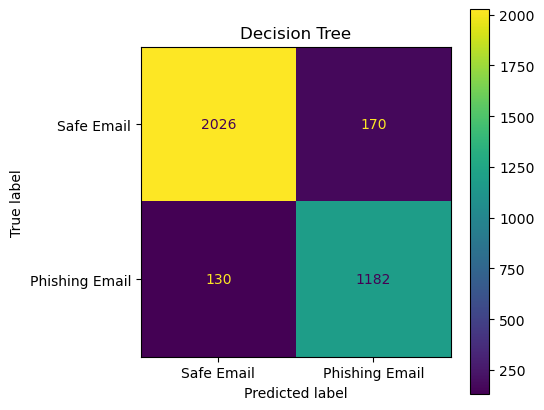



Random Forest


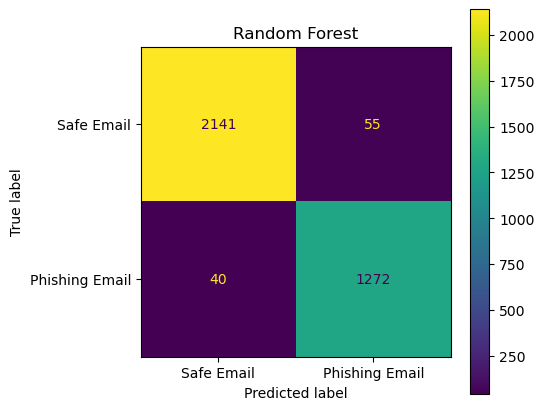



Neural Network


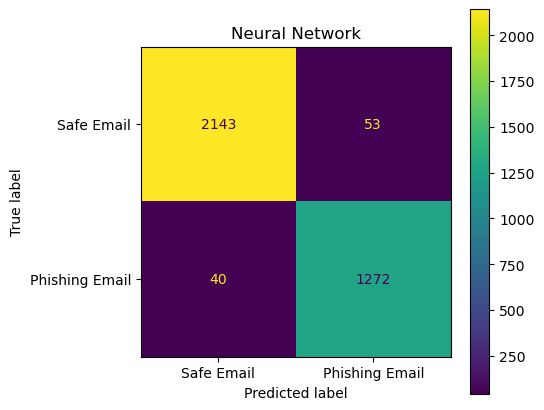



Naive Bayes


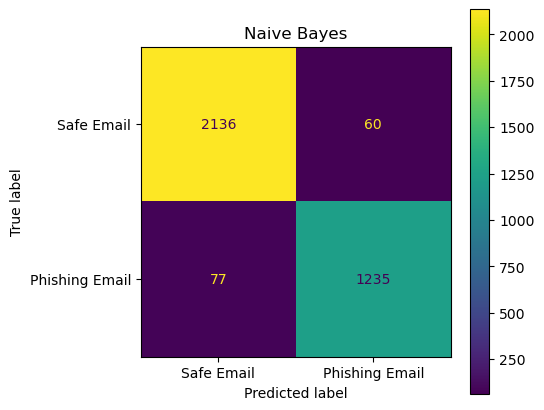



Linear SVM


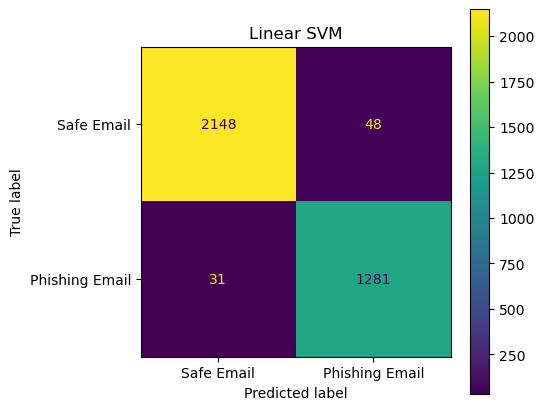

In [ ]:
# ==========================================================
# STEP 14 : CONFUSION MATRICES
# ==========================================================

for name, model in trained_models.items():

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Safe Email", "Phishing Email"]
    )

    fig, ax = plt.subplots(figsize=(5,5))

    disp.plot(ax=ax)

    plt.title(name)

    plt.show()

In [ ]:
# ==========================================================
# STEP 15 : IDENTIFY THE BEST MODEL
# ==========================================================

print("=" * 70)
print("BEST MODEL IDENTIFICATION")
print("=" * 70)

best_model_name = results_df.iloc[0]["Model"]
best_accuracy = results_df.iloc[0]["Accuracy"]

print(f"\nBest Model       : {best_model_name}")
print(f"Testing Accuracy : {best_accuracy:.4f}")

best_model = trained_models[best_model_name]

print("\nThe best-performing model has been selected successfully.")

BEST MODEL IDENTIFICATION

Best Model       : Linear SVM
Testing Accuracy : 0.9775

The best-performing model has been selected successfully.


In [ ]:
# ==========================================================
# STEP 16 : CUSTOM EMAIL PREDICTION
# ==========================================================

def predict_email(email_text):
    """
    Predict whether an email is Safe or Phishing.
    """

    # Convert to lowercase
    email_text = email_text.lower()

    # Remove URLs
    email_text = re.sub(r'http\S+|www\S+|https\S+', '', email_text)

    # Remove HTML tags
    email_text = re.sub(r'<.*?>', '', email_text)

    # Remove punctuation
    email_text = email_text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    email_text = re.sub(r'\d+', '', email_text)

    # Remove extra spaces
    email_text = re.sub(r'\s+', ' ', email_text)

    # Remove stop words
    words = email_text.split()

    words = [word for word in words if word not in stop_words]

    cleaned_text = " ".join(words)

    # Convert into TF-IDF features
    transformed_text = vectorizer.transform([cleaned_text])

    # Predict
    prediction = best_model.predict(transformed_text)[0]

    print("\nPrediction Result")
    print("-" * 40)

    if prediction == 0:
        print("Safe Email")
    else:
        print("Phishing Email")

In [ ]:
# ==========================================================
# STEP 17 : TEST THE MODEL
# ==========================================================

sample_email = """
Dear Customer,

Your bank account has been temporarily suspended due to suspicious activity.

Please click the link below and verify your account immediately to avoid permanent suspension.

http://verify-account-now.com

Thank you.
"""

predict_email(sample_email)


Prediction Result
----------------------------------------
Phishing Email
